# Exploring `physkit.periodic`

This notebook validates the shared mathematical infrastructure for one-dimensional periodic systems. It constructs the direct lattice, reciprocal lattice, first Brillouin zone, reciprocal-mode basis, Bloch phase, and a generic Bloch mode.

The notebook does not construct an electronic Hamiltonian or a phonon dynamical matrix. Those are domain-specific operators built after the periodic representation has been defined.

## 1. Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from physkit.periodic import (
    DirectLattice1D,
    KPointPath1D,
    ReciprocalLattice1D,
    ReciprocalModeBasis1D,
)

## 2. Direct lattice

A one-dimensional Bravais lattice contains translations

$$
R_n=na.
$$



In [2]:
lattice_constant = 1.5

direct_lattice = DirectLattice1D(
    lattice_constant=lattice_constant,
)

cell_indices = np.arange(-4, 5)
translations = np.array([
    direct_lattice.translation(cell_index)
    for cell_index in cell_indices
])

print("Cell indices:", cell_indices)
print("Translations:", translations)

Cell indices: [-4 -3 -2 -1  0  1  2  3  4]
Translations: [-6.  -4.5 -3.  -1.5  0.   1.5  3.   4.5  6. ]


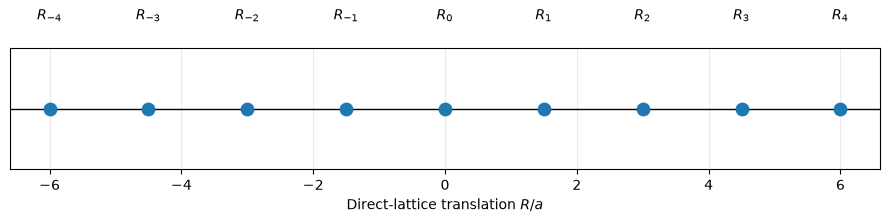

In [22]:
fig, ax = plt.subplots(figsize=(9, 2.5))

ax.scatter(
    translations,
    np.zeros_like(translations),
    s=80,
    color="tab:blue",
    zorder=3,
)

for cell_index, translation in zip(cell_indices, translations):
    ax.text(
        translation,
        0.08,
        rf"$R_{{{cell_index}}}$",
        ha="center",
    )

ax.axhline(0.0, color="black", linewidth=1.0)
ax.set_xlabel(r"Direct-lattice translation $R/a$")
ax.set_yticks([])
#ax.set_title("One-Dimensional Direct Lattice")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Reciprocal lattice

The fundamental reciprocal vector is

$$
G_0=\frac{2\pi}{a},
$$

and reciprocal vectors are $G_m=mG_0$.

In [4]:
reciprocal_lattice = ReciprocalLattice1D(
    direct_lattice=direct_lattice,
)

G0 = reciprocal_lattice.fundamental_vector

print(f"a   = {direct_lattice.lattice_constant:.6f}")
print(f"G_0 = {G0:.6f}")
print(f"a G_0 = {direct_lattice.lattice_constant * G0:.6f}")
print(f"2 pi  = {2.0 * np.pi:.6f}")

assert np.isclose(
    direct_lattice.lattice_constant * G0,
    2.0 * np.pi,
)

a   = 1.500000
G_0 = 4.188790
a G_0 = 6.283185
2 pi  = 6.283185


### Reciprocal periodicity test

For every pair of integer indices $m$ and $n$,

$$
e^{iG_mR_n}=1.
$$

In [5]:
reciprocal_modes = np.arange(-3, 4)
reciprocal_vectors = reciprocal_modes * G0

reciprocal_phases = np.exp(
    1j
    * reciprocal_vectors[:, None]
    * translations[None, :]
)

maximum_periodicity_error = np.max(
    np.abs(reciprocal_phases - 1.0)
)

print(
    "Maximum reciprocal-periodicity error:",
    maximum_periodicity_error,
)

assert np.allclose(reciprocal_phases, 1.0)

Maximum reciprocal-periodicity error: 2.9391523179536475e-15


## 4. First Brillouin zone

In one dimension, the first Brillouin zone is

$$
-\frac{G_0}{2}\leq k\leq+\frac{G_0}{2}.
$$

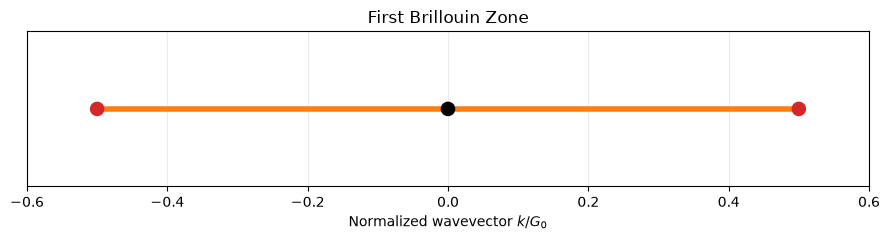

In [6]:
k_path = KPointPath1D.first_brillouin_zone(
    reciprocal_lattice=reciprocal_lattice,
    number_of_points=301,
)

fig, ax = plt.subplots(figsize=(9, 2.5))

ax.plot(
    k_path.values / G0,
    np.zeros_like(k_path.values),
    linewidth=4.0,
    color="tab:orange",
)

ax.scatter(
    [-0.5, 0.0, 0.5],
    [0.0, 0.0, 0.0],
    s=90,
    color=["tab:red", "black", "tab:red"],
    zorder=3,
)

ax.set_xlim(-0.6, 0.6)
ax.set_ylim(-0.2, 0.2)
ax.set_xlabel(r"Normalized wavevector $k/G_0$")
ax.set_yticks([])
ax.set_title("First Brillouin Zone")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Reciprocal-mode basis

The cell-periodic field is represented as

$$
u_k(x)=\sum_G c_k(G)e^{iGx}.
$$

In [7]:
basis = ReciprocalModeBasis1D.from_mode_limit(
    reciprocal_lattice=reciprocal_lattice,
    mode_limit=3,
)

print("Modes:", basis.modes)
print("Reciprocal vectors:", basis.vectors)
print("Basis size:", basis.size)

Modes: [-3 -2 -1  0  1  2  3]
Reciprocal vectors: [-12.56637061  -8.37758041  -4.1887902    0.           4.1887902
   8.37758041  12.56637061]
Basis size: 7


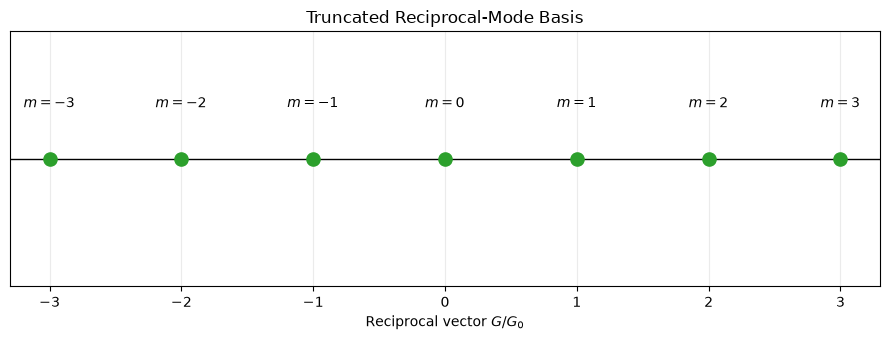

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.5))

ax.scatter(
    basis.vectors / G0,
    np.zeros(basis.size),
    s=90,
    color="tab:green",
    zorder=3,
)

for mode, vector in zip(basis.modes, basis.vectors):
    ax.text(
        vector / G0,
        0.08,
        rf"$m={mode}$",
        ha="center",
    )

ax.axhline(0.0, color="black", linewidth=1.0)
ax.set_ylim(-0.2, 0.2)
ax.set_xlabel(r"Reciprocal vector $G/G_0$")
ax.set_yticks([])
ax.set_title("Truncated Reciprocal-Mode Basis")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Bloch phase

A Bloch mode is an eigenfunction of lattice translation:

$$
f_k(x+R)=e^{ikR}f_k(x).
$$

In [9]:
k = 0.30 * G0

translation_phases = np.exp(
    1j * k * translations
)

for R, phase_value in zip(translations, translation_phases):
    print(
        f"R = {R:+.1f} a, "
        f"exp(i k R) = {phase_value.real:+.4f} "
        f"{phase_value.imag:+.4f}j"
    )

R = -6.0 a, exp(i k R) = +0.3090 -0.9511j
R = -4.5 a, exp(i k R) = +0.8090 +0.5878j
R = -3.0 a, exp(i k R) = -0.8090 +0.5878j
R = -1.5 a, exp(i k R) = -0.3090 -0.9511j
R = +0.0 a, exp(i k R) = +1.0000 +0.0000j
R = +1.5 a, exp(i k R) = -0.3090 +0.9511j
R = +3.0 a, exp(i k R) = -0.8090 -0.5878j
R = +4.5 a, exp(i k R) = +0.8090 -0.5878j
R = +6.0 a, exp(i k R) = +0.3090 +0.9511j


### Equivalent wavevectors

Wavevectors $k$ and $k+G_m$ have identical lattice-translation eigenvalues.

In [10]:
shifted_k = k + 2.0 * G0

phases_at_k = np.exp(1j * k * translations)
phases_at_shifted_k = np.exp(1j * shifted_k * translations)

equivalence_error = np.max(
    np.abs(phases_at_k - phases_at_shifted_k)
)

print("Maximum equivalence error:", equivalence_error)
assert np.allclose(phases_at_k, phases_at_shifted_k)

Maximum equivalence error: 4.130268402344377e-15


## 7. Generic Bloch mode

We now choose arbitrary normalized Fourier coefficients and construct

$$
u_k(x)=\sum_G c_k(G)e^{iGx}
$$

and

$$
f_k(x)=e^{ikx}u_k(x).
$$

The coefficients are illustrative representation data; they are not yet eigenvectors of an electronic or phonon operator.

In [12]:
coefficients = np.exp(
    -0.55 * basis.modes.astype(float) ** 2
).astype(np.complex128)

coefficients *= np.exp(
    0.25j * basis.modes
)

coefficients /= np.linalg.norm(coefficients)

print("Coefficient norm:", np.linalg.norm(coefficients))
print("Reciprocal weights:", np.abs(coefficients) ** 2)

Coefficient norm: 1.0
Reciprocal weights: [2.96821848e-05 7.26299116e-03 1.96918857e-01 5.91576939e-01
 1.96918857e-01 7.26299116e-03 2.96821848e-05]


In [15]:
number_of_cells = 4
x = np.linspace(
    0.0,
    number_of_cells * direct_lattice.lattice_constant,
    1201,
)

plane_waves = np.exp(
    1j
    * basis.vectors[:, None]
    * x[None, :]
)

periodic_part = coefficients @ plane_waves
complete_mode = (
    np.exp(1j * k * x)
    * periodic_part
)

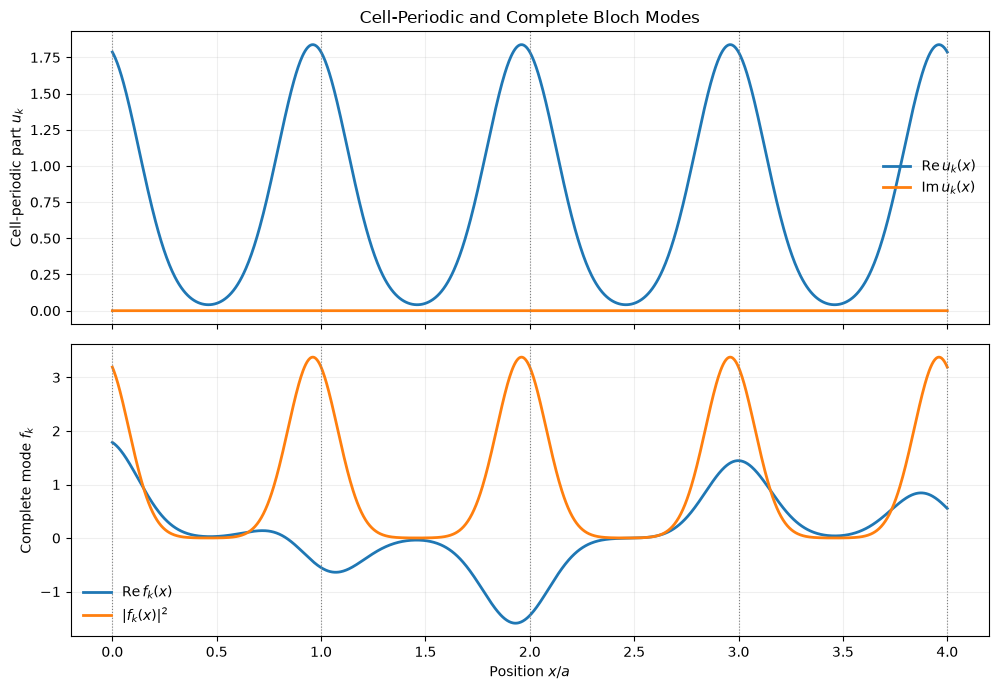

In [18]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 7),
    sharex=True,
)

axes[0].plot(
    x / direct_lattice.lattice_constant,
    periodic_part.real,
    label=r"$\operatorname{Re}u_k(x)$",
    linewidth=2.0,
)
axes[0].plot(
    x / direct_lattice.lattice_constant,
    periodic_part.imag,
    label=r"$\operatorname{Im}u_k(x)$",
    linewidth=2.0,
)
axes[0].set_ylabel(r"Cell-periodic part $u_k$")
axes[0].set_title("Cell-Periodic and Complete Bloch Modes")
axes[0].legend(frameon=False)

axes[1].plot(
    x / direct_lattice.lattice_constant,
    complete_mode.real,
    label=r"$\operatorname{Re}f_k(x)$",
    linewidth=2.0,
)
axes[1].plot(
    x / direct_lattice.lattice_constant,
    np.abs(complete_mode) ** 2,
    label=r"$|f_k(x)|^2$",
    linewidth=2.0,
)
axes[1].set_xlabel(r"Position $x/a$")
axes[1].set_ylabel(r"Complete mode $f_k$")
axes[1].legend(frameon=False)

for ax in axes:
    for cell_boundary in range(number_of_cells + 1):
        ax.axvline(
            cell_boundary,
            color="gray",
            linestyle=":",
            linewidth=0.8,
        )
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 8. Numerical Bloch-condition test

We verify

$$
u_k(x+a)=u_k(x)
$$

and

$$
f_k(x+a)=e^{ika}f_k(x).
$$

In [21]:
x_cell = np.linspace(
    0.0,
    direct_lattice.lattice_constant,
    401,
)

plane_waves_x = np.exp(
    1j
    * basis.vectors[:, None]
    * x_cell[None, :]
)
plane_waves_x_plus_a = np.exp(
    1j
    * basis.vectors[:, None]
    * (x_cell + direct_lattice.lattice_constant)[None, :]
)

u_x = coefficients @ plane_waves_x
u_x_plus_a = coefficients @ plane_waves_x_plus_a

f_x = np.exp(1j * k * x_cell) * u_x
f_x_plus_a = (
    np.exp(
        1j
        * k
        * (x_cell + direct_lattice.lattice_constant)
    )
    * u_x_plus_a
)

expected_translated_mode = (
    np.exp(
        1j
        * k
        * direct_lattice.lattice_constant
    )
    * f_x
)

periodic_part_error = np.max(
    np.abs(u_x_plus_a - u_x)
)

bloch_condition_error = np.max(
    np.abs(
        f_x_plus_a
        - expected_translated_mode
    )
)

print("Cell-periodicity error:", periodic_part_error)
print("Bloch-condition error:", bloch_condition_error)

assert np.allclose(u_x_plus_a, u_x)
assert np.allclose(
    f_x_plus_a,
    expected_translated_mode,
)

Cell-periodicity error: 2.5535358677242728e-15
Bloch-condition error: 2.5637593222557704e-15


## 9. Representation boundary

At this point, the periodic state space is defined:

$$
\mathcal H
=
\bigoplus_k\mathcal H_k.
$$

The next layer supplies a physical operator within each wavevector sector. For electrons this is $H(k)$; for phonons it is $D(q)$. The `periodic` subpackage supplies the common translation representation, while the domain package determines what is diagonalized and how its eigenvalues are interpreted.